# OmniTypist — Results Analysis

Four simulation experiments:
1. **Mode comparison** — single-finger vs two-thumb vs chording
2. **Vocabulary size** — 2 / 5 / 10 chords
3. **Difficulty assignment** — uniform-easy / medium / graduated / hard
4. **Individual differences** — high / fitted / low working-memory capacity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Load all four result files
mode_df   = pd.read_csv('results/mode.csv')
vocab_df  = pd.read_csv('results/vocab_size.csv')
diff_df   = pd.read_csv('results/difficulty.csv')
indiv_df  = pd.read_csv('results/individual_diff.csv')

# Convenience: compute percentage versions
for df in [mode_df, vocab_df, diff_df, indiv_df]:
    df['error_pct']       = df['char_error_rate'] * 100
    df['gaze_kbd_pct']    = df['gaze_kbd_ratio']  * 100
    df['fire_rate_pct']   = df['fire_rate']        * 100
    df['chord_cov_pct']   = df['chord_coverage']   * 100

print('Episode counts:')
for name, df in [('mode', mode_df), ('vocab_size', vocab_df),
                 ('difficulty', diff_df), ('individual_diff', indiv_df)]:
    print(f'  {name}: {df.groupby("condition").size().to_dict()}')

Episode counts:
  mode: {'chording': 28, 'single-finger': 27, 'two-thumb': 30}
  vocab_size: {'vocab-10': 28, 'vocab-2': 28, 'vocab-5': 28}
  difficulty: {'graduated': 28, 'uniform-easy': 28, 'uniform-hard': 28, 'uniform-medium': 28}
  individual_diff: {'fitted-memory': 28, 'high-memory': 28, 'low-memory': 28}


In [2]:
# ── Helper: grouped bar chart with individual data points ─────────────────────
def bar_chart(df, metric, order, colors, ylabel, title, ax, fmt='.1f', ylim=None):
    means = df.groupby('condition')[metric].mean().reindex(order)
    sds   = df.groupby('condition')[metric].std().reindex(order)
    x = np.arange(len(order))
    bars = ax.bar(x, means, color=colors, alpha=0.85, width=0.55,
                  yerr=sds, capsize=4, error_kw={'linewidth': 1.2})
    # Overlay individual points
    for i, cond in enumerate(order):
        vals = df[df['condition'] == cond][metric].values
        ax.scatter(np.random.normal(i, 0.07, len(vals)), vals,
                   color='black', alpha=0.3, s=14, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    if ylim:
        ax.set_ylim(ylim)
    # Label bars
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + sds[order[bars.patches.index(bar)]] * 0.05,
                f'{mean:{fmt}}', ha='center', va='bottom', fontsize=9)

# Alternative that avoids index gymnastics
def bar_chart2(df, metric, order, colors, ylabel, title, ax, fmt='.1f', ylim=None):
    means = [df[df['condition']==c][metric].mean() for c in order]
    sds   = [df[df['condition']==c][metric].std()  for c in order]
    x = np.arange(len(order))
    bars = ax.bar(x, means, color=colors, alpha=0.85, width=0.55,
                  yerr=sds, capsize=4, error_kw={'linewidth': 1.2})
    for i, cond in enumerate(order):
        vals = df[df['condition'] == cond][metric].values
        ax.scatter(np.random.normal(i, 0.07, len(vals)), vals,
                   color='black', alpha=0.25, s=14, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    if ylim: ax.set_ylim(ylim)
    for bar, m, s in zip(bars, means, sds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s * 0.05 + (ylim[0] if ylim else 0) * 0.0,
                f'{m:{fmt}}', ha='center', va='bottom', fontsize=9)

print('Helpers loaded.')

Helpers loaded.


---
## Experiment 1 — Typing Mode Comparison

**Question:** Does adding a second thumb and then chording improve typing performance, and what are the tradeoffs?

We simulate 30 episodes per mode using the same target phrases and the same fitted perceptual-motor parameters.

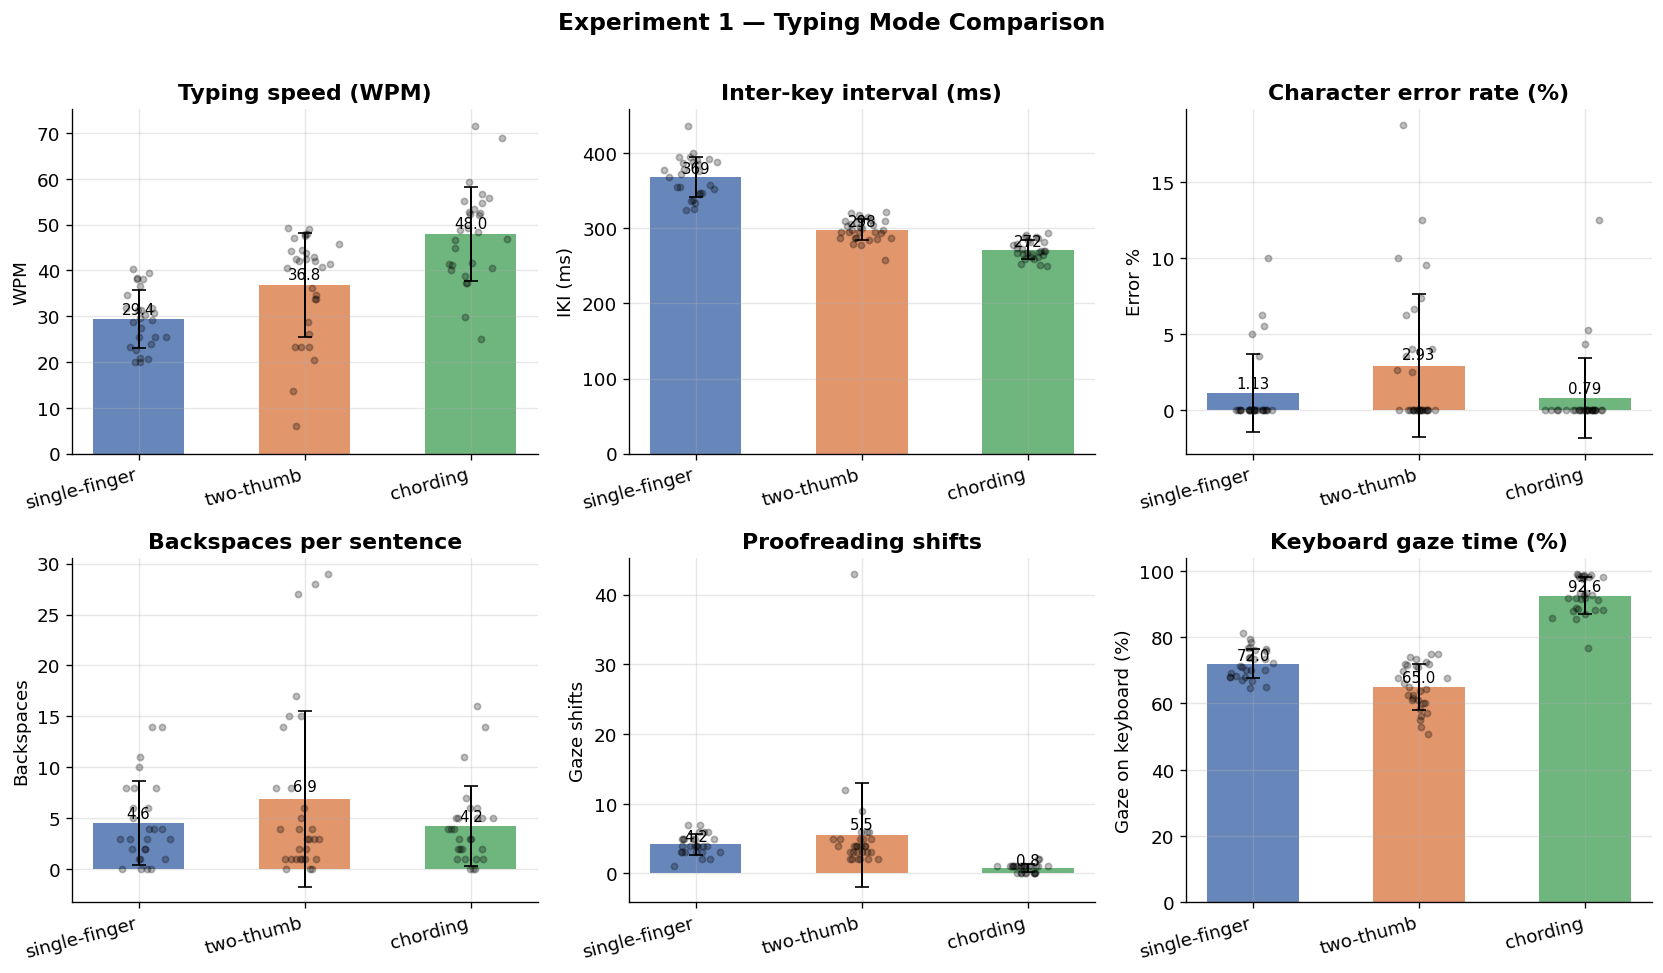

In [3]:
ORDER_MODE   = ['single-finger', 'two-thumb', 'chording']
COLORS_MODE  = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Experiment 1 — Typing Mode Comparison', fontsize=14, fontweight='bold', y=1.01)

specs = [
    ('WPM',           'WPM',                'Typing speed (WPM)',       '.1f'),
    ('IKI',           'IKI (ms)',            'Inter-key interval (ms)',  '.0f'),
    ('error_pct',     'Error %',             'Character error rate (%)', '.2f'),
    ('num_backspaces','Backspaces',          'Backspaces per sentence',  '.1f'),
    ('gaze_shift',    'Gaze shifts',         'Proofreading shifts',      '.1f'),
    ('gaze_kbd_pct',  'Gaze on keyboard (%)', 'Keyboard gaze time (%)', '.1f'),
]

for ax, (metric, ylabel, title, fmt) in zip(axes.flat, specs):
    bar_chart2(mode_df, metric, ORDER_MODE, COLORS_MODE, ylabel, title, ax, fmt)

plt.tight_layout()
plt.savefig('results/exp1_mode.png', bbox_inches='tight')
plt.show()

In [4]:
# Summary table
metrics = ['WPM', 'IKI', 'error_pct', 'num_backspaces', 'gaze_shift', 'gaze_kbd_pct']
labels  = ['WPM', 'IKI (ms)', 'Error %', 'Backspaces', 'Gaze shifts', 'Gaze on kbd %']

rows = []
for cond in ORDER_MODE:
    sub = mode_df[mode_df['condition'] == cond]
    row = {'Condition': cond, 'n': len(sub)}
    for m, l in zip(metrics, labels):
        row[l] = f"{sub[m].mean():.2f} ({sub[m].std():.2f})"
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Condition')
print('Mean (SD) per condition:')
print(summary.to_string())

Mean (SD) per condition:
                n            WPM        IKI (ms)      Error %   Backspaces  Gaze shifts Gaze on kbd %
Condition                                                                                            
single-finger  27   29.45 (6.34)  368.66 (26.96)  1.13 (2.58)  4.56 (4.12)  4.19 (1.49)  72.05 (4.47)
two-thumb      30  36.84 (11.33)  298.22 (14.18)  2.93 (4.69)  6.90 (8.61)  5.50 (7.40)  65.03 (6.96)
chording       28  47.96 (10.36)  271.58 (12.36)  0.79 (2.62)  4.21 (3.93)  0.75 (0.59)  92.55 (5.52)


In [5]:
# Statistical tests: pairwise t-tests on WPM
print('Pairwise Welch t-tests on WPM (two-tailed):')
pairs = [('single-finger','two-thumb'), ('two-thumb','chording'), ('single-finger','chording')]
for a, b in pairs:
    va = mode_df[mode_df['condition']==a]['WPM']
    vb = mode_df[mode_df['condition']==b]['WPM']
    t, p = stats.ttest_ind(va, vb, equal_var=False)
    delta = vb.mean() - va.mean()
    print(f'  {a} vs {b}: Δ={delta:+.2f} WPM, t={t:.2f}, p={p:.4f} {"*" if p<0.05 else "ns"}')

Pairwise Welch t-tests on WPM (two-tailed):
  single-finger vs two-thumb: Δ=+7.40 WPM, t=-3.08, p=0.0035 *
  two-thumb vs chording: Δ=+11.12 WPM, t=-3.90, p=0.0003 *
  single-finger vs chording: Δ=+18.51 WPM, t=-8.03, p=0.0000 *


In [6]:
# Chord-specific stats for chording mode
chord_ep = mode_df[mode_df['condition'] == 'chording']
print('Chording mode — chord-specific metrics:')
print(f"  Chord attempts per episode : {chord_ep['chord_attempts'].mean():.1f} ± {chord_ep['chord_attempts'].std():.1f}")
print(f"  Chords fired per episode   : {chord_ep['chords_fired'].mean():.1f}   ± {chord_ep['chords_fired'].std():.1f}")
print(f"  Fire rate                  : {chord_ep['fire_rate_pct'].mean():.1f}% ± {chord_ep['fire_rate_pct'].std():.1f}%")
print(f"  Chord coverage (target)    : {chord_ep['chord_cov_pct'].mean():.1f}% ± {chord_ep['chord_cov_pct'].std():.1f}%")
print()
print('Interpretation: on sentences where coverage > 0, the model uses chords',
      'to produce multiple characters in one supervisor step.')

Chording mode — chord-specific metrics:
  Chord attempts per episode : 0.5 ± 0.9
  Chords fired per episode   : 0.5   ± 0.7
  Fire rate                  : 34.8% ± 47.8%
  Chord coverage (target)    : 7.0% ± 9.8%

Interpretation: on sentences where coverage > 0, the model uses chords to produce multiple characters in one supervisor step.


---
## Experiment 2 — Chord Vocabulary Size

**Question:** Does a larger chord vocabulary improve performance, or does the added recall burden offset the coverage gains?

The supervisor checkpoint is unchanged; only the active vocabulary (2 / 5 / 10 chords) is swapped at inference time.

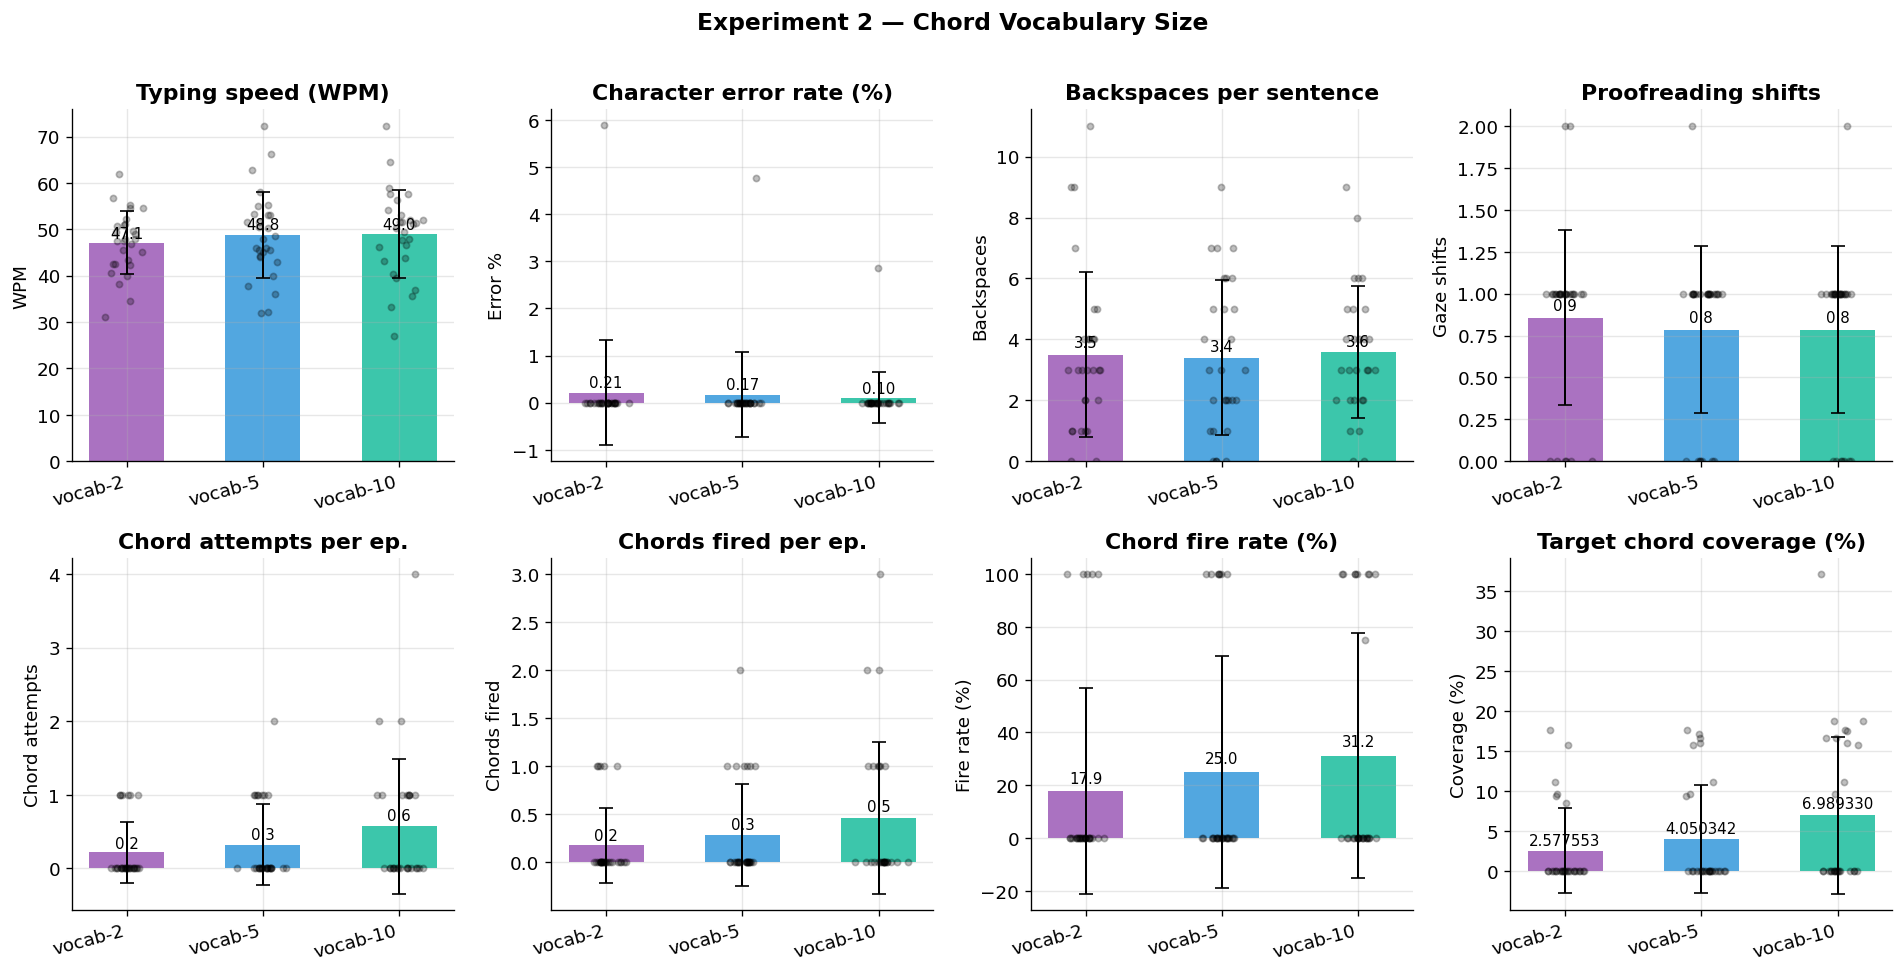

In [7]:
ORDER_VOCAB  = ['vocab-2', 'vocab-5', 'vocab-10']
COLORS_VOCAB = ['#9B59B6', '#3498DB', '#1ABC9C']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Experiment 2 — Chord Vocabulary Size', fontsize=14, fontweight='bold', y=1.01)

specs2 = [
    ('WPM',            'WPM',                'Typing speed (WPM)',       '.1f'),
    ('error_pct',      'Error %',            'Character error rate (%)', '.2f'),
    ('num_backspaces', 'Backspaces',         'Backspaces per sentence',  '.1f'),
    ('gaze_shift',     'Gaze shifts',        'Proofreading shifts',      '.1f'),
    ('chord_attempts', 'Chord attempts',     'Chord attempts per ep.',   '.1f'),
    ('chords_fired',   'Chords fired',       'Chords fired per ep.',     '.1f'),
    ('fire_rate_pct',  'Fire rate (%)',       'Chord fire rate (%)',      '.1f'),
    ('chord_cov_pct',  'Coverage (%)',        'Target chord coverage (%)','1f'),
]

for ax, (metric, ylabel, title, fmt) in zip(axes.flat, specs2):
    bar_chart2(vocab_df, metric, ORDER_VOCAB, COLORS_VOCAB, ylabel, title, ax, fmt)

plt.tight_layout()
plt.savefig('results/exp2_vocab_size.png', bbox_inches='tight')
plt.show()

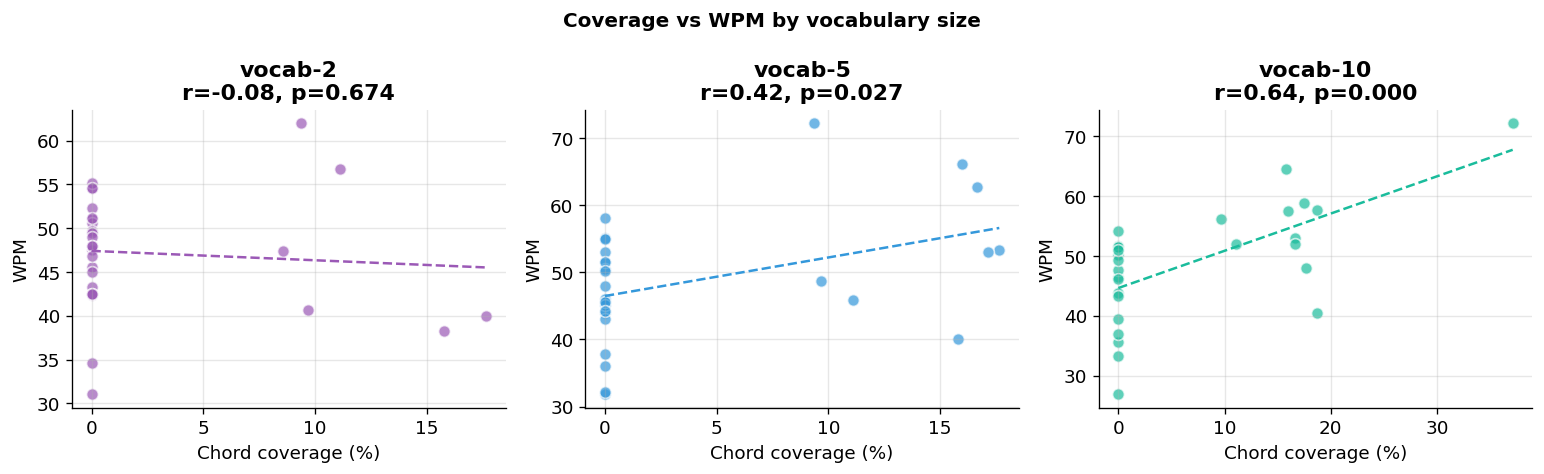

Each point = one episode. Trend line shows correlation between available coverage and typing speed.


In [8]:
# Coverage vs WPM scatter: each point is one episode
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Coverage vs WPM by vocabulary size', fontsize=12, fontweight='bold')

for ax, (cond, color) in zip(axes, zip(ORDER_VOCAB, COLORS_VOCAB)):
    sub = vocab_df[vocab_df['condition'] == cond]
    ax.scatter(sub['chord_cov_pct'], sub['WPM'], color=color, alpha=0.7, edgecolors='white', s=50)
    if len(sub) > 2:
        m, b, r, p, _ = stats.linregress(sub['chord_cov_pct'], sub['WPM'])
        xs = np.linspace(sub['chord_cov_pct'].min(), sub['chord_cov_pct'].max(), 50)
        ax.plot(xs, m*xs + b, color=color, linewidth=1.5, linestyle='--')
        ax.set_title(f"{cond}\nr={r:.2f}, p={p:.3f}", fontweight='bold')
    else:
        ax.set_title(cond, fontweight='bold')
    ax.set_xlabel('Chord coverage (%)')
    ax.set_ylabel('WPM')

plt.tight_layout()
plt.savefig('results/exp2_coverage_wpm.png', bbox_inches='tight')
plt.show()
print('Each point = one episode. Trend line shows correlation between available coverage and typing speed.')

In [9]:
# Summary table
metrics2 = ['WPM', 'error_pct', 'chord_attempts', 'chords_fired', 'fire_rate_pct', 'chord_cov_pct']
labels2  = ['WPM', 'Error %', 'Attempts', 'Fired', 'Fire rate %', 'Coverage %']

rows = []
for cond in ORDER_VOCAB:
    sub = vocab_df[vocab_df['condition'] == cond]
    row = {'Vocab': cond, 'n': len(sub)}
    for m, l in zip(metrics2, labels2):
        row[l] = f"{sub[m].mean():.2f} ({sub[m].std():.2f})"
    rows.append(row)
print(pd.DataFrame(rows).set_index('Vocab').to_string())

           n           WPM      Error %     Attempts        Fired    Fire rate %   Coverage %
Vocab                                                                                        
vocab-2   28  47.14 (6.80)  0.21 (1.11)  0.21 (0.42)  0.18 (0.39)  17.86 (39.00)  2.58 (5.28)
vocab-5   28  48.80 (9.31)  0.17 (0.90)  0.32 (0.55)  0.29 (0.53)  25.00 (44.10)  4.05 (6.76)
vocab-10  28  48.99 (9.56)  0.10 (0.54)  0.57 (0.92)  0.46 (0.79)  31.25 (46.46)  6.99 (9.83)


---
## Experiment 3 — Difficulty Assignment

**Question:** Does the graduated difficulty scheme (harder chords decay faster) produce different recall behavior compared to flat difficulty assignments?

All four conditions use the full 10-chord vocabulary; only the per-chord decay rates vary.

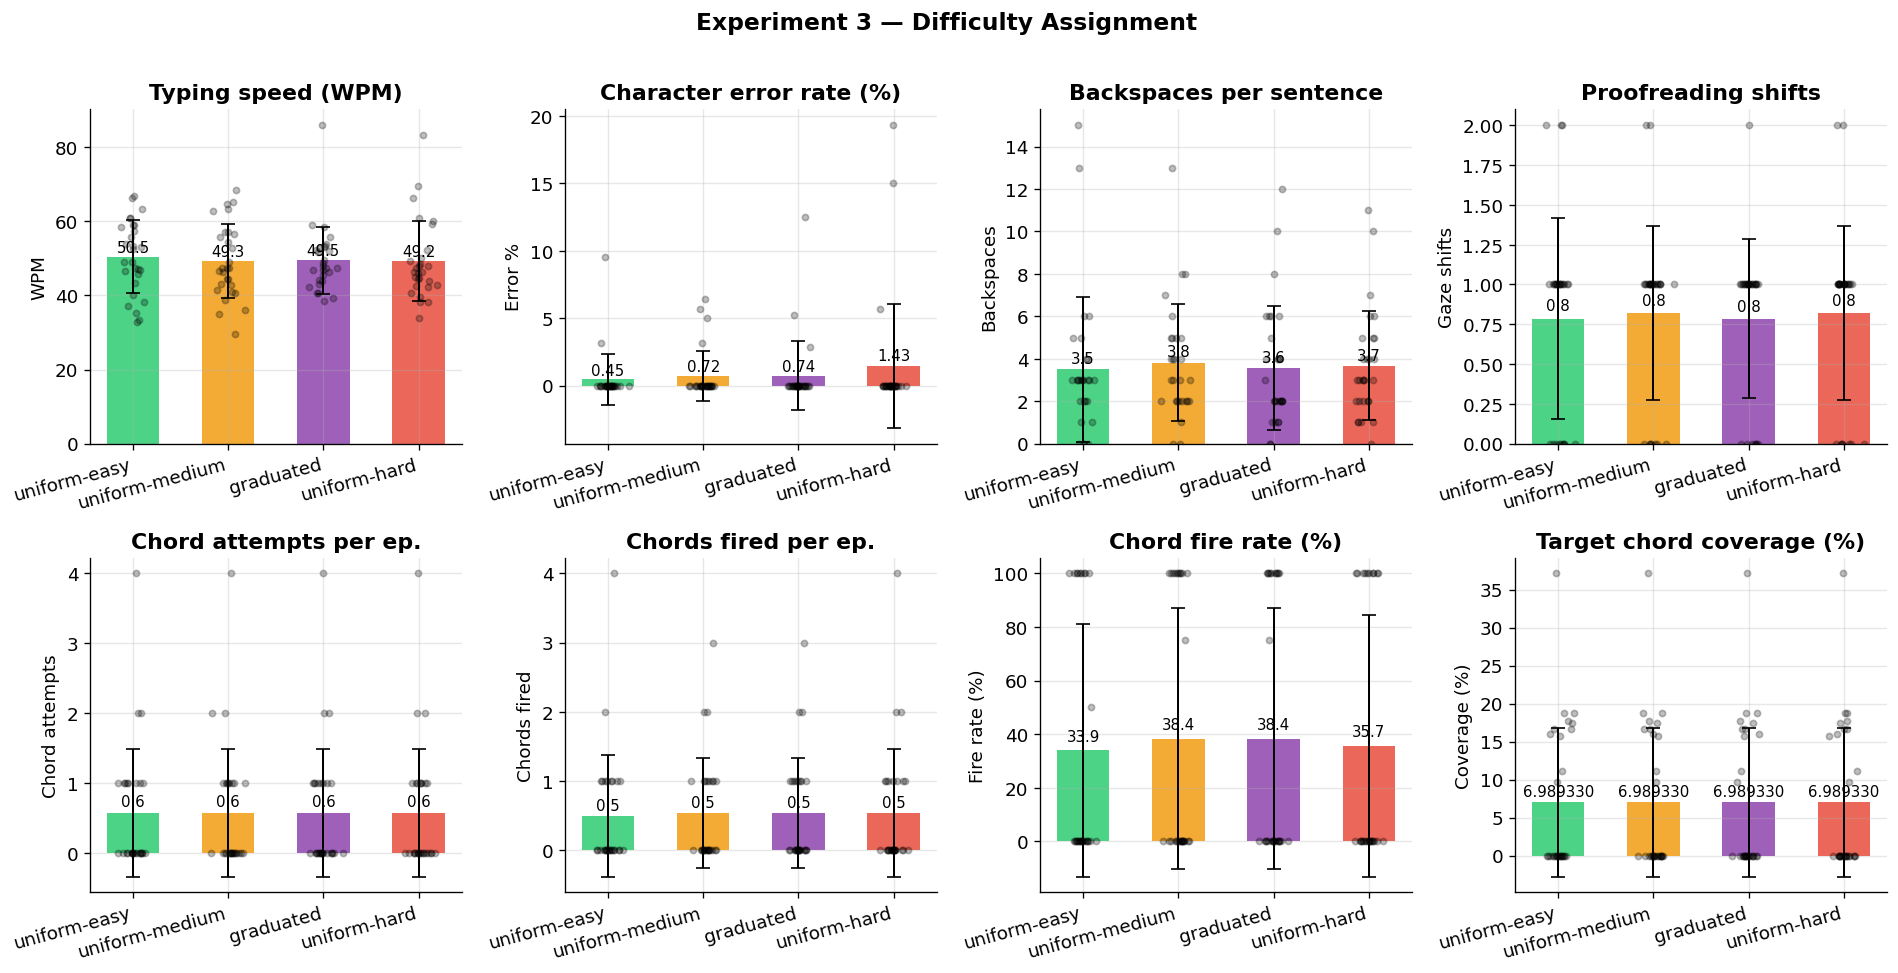

In [10]:
ORDER_DIFF  = ['uniform-easy', 'uniform-medium', 'graduated', 'uniform-hard']
COLORS_DIFF = ['#2ECC71', '#F39C12', '#8E44AD', '#E74C3C']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Experiment 3 — Difficulty Assignment', fontsize=14, fontweight='bold', y=1.01)

for ax, (metric, ylabel, title, fmt) in zip(axes.flat, specs2):
    bar_chart2(diff_df, metric, ORDER_DIFF, COLORS_DIFF, ylabel, title, ax, fmt)

plt.tight_layout()
plt.savefig('results/exp3_difficulty.png', bbox_inches='tight')
plt.show()

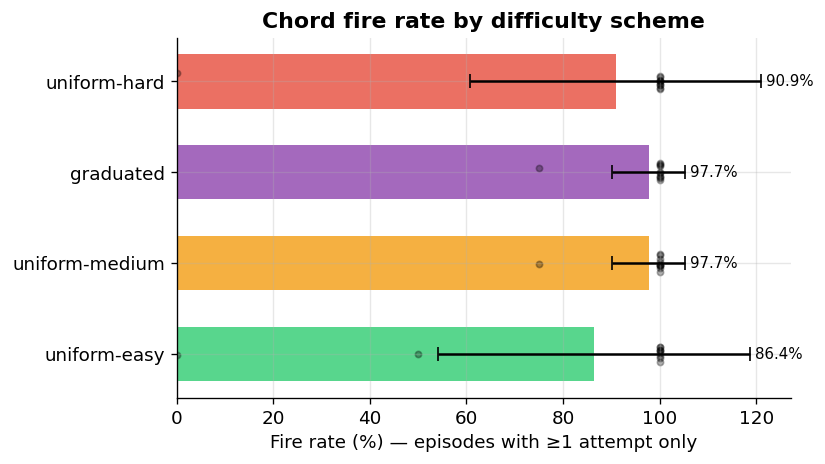

In [11]:
# Fire rate by condition — the most direct signal of difficulty effect
fig, ax = plt.subplots(figsize=(7, 4))
for i, (cond, color) in enumerate(zip(ORDER_DIFF, COLORS_DIFF)):
    sub = diff_df[diff_df['condition'] == cond]
    # Only episodes where a chord was attempted
    attempted = sub[sub['chord_attempts'] > 0]
    if len(attempted) == 0:
        continue
    rates = attempted['fire_rate_pct']
    ax.barh(i, rates.mean(), color=color, alpha=0.8,
            xerr=rates.std(), capsize=4, height=0.6)
    ax.scatter(rates, np.full(len(rates), i) + np.random.uniform(-0.1, 0.1, len(rates)),
               color='black', alpha=0.3, s=14)
    ax.text(rates.mean() + rates.std() + 1, i, f"{rates.mean():.1f}%",
            va='center', fontsize=9)

ax.set_yticks(range(len(ORDER_DIFF)))
ax.set_yticklabels(ORDER_DIFF)
ax.set_xlabel('Fire rate (%) — episodes with ≥1 attempt only')
ax.set_title('Chord fire rate by difficulty scheme', fontweight='bold')
plt.tight_layout()
plt.savefig('results/exp3_fire_rate.png', bbox_inches='tight')
plt.show()

In [12]:
# What fraction of episodes had any chord attempts?
print('Fraction of episodes with ≥1 chord attempt:')
for cond in ORDER_DIFF:
    sub = diff_df[diff_df['condition'] == cond]
    frac = (sub['chord_attempts'] > 0).mean()
    mean_attempts = sub['chord_attempts'].mean()
    print(f"  {cond:<20s}  {frac:.0%} of episodes  |  mean attempts = {mean_attempts:.1f}")

print()
print('WPM summary:')
for cond in ORDER_DIFF:
    sub = diff_df[diff_df['condition'] == cond]
    print(f"  {cond:<20s}  {sub['WPM'].mean():.1f} ± {sub['WPM'].std():.1f} WPM")

Fraction of episodes with ≥1 chord attempt:
  uniform-easy          39% of episodes  |  mean attempts = 0.6
  uniform-medium        39% of episodes  |  mean attempts = 0.6
  graduated             39% of episodes  |  mean attempts = 0.6
  uniform-hard          39% of episodes  |  mean attempts = 0.6

WPM summary:
  uniform-easy          50.5 ± 9.8 WPM
  uniform-medium        49.3 ± 10.1 WPM
  graduated             49.5 ± 9.0 WPM
  uniform-hard          49.2 ± 10.8 WPM


---
## Experiment 4 — Individual Differences

**Question:** How does working-memory capacity interact with chording? Does weaker memory hurt chord performance more than sequential typing?

- **high-memory** (memory_p = 0.1): slow decay, large working-memory window
- **fitted-memory** (memory_p = 0.321): population-average
- **low-memory** (memory_p = 0.8): fast decay, small effective memory

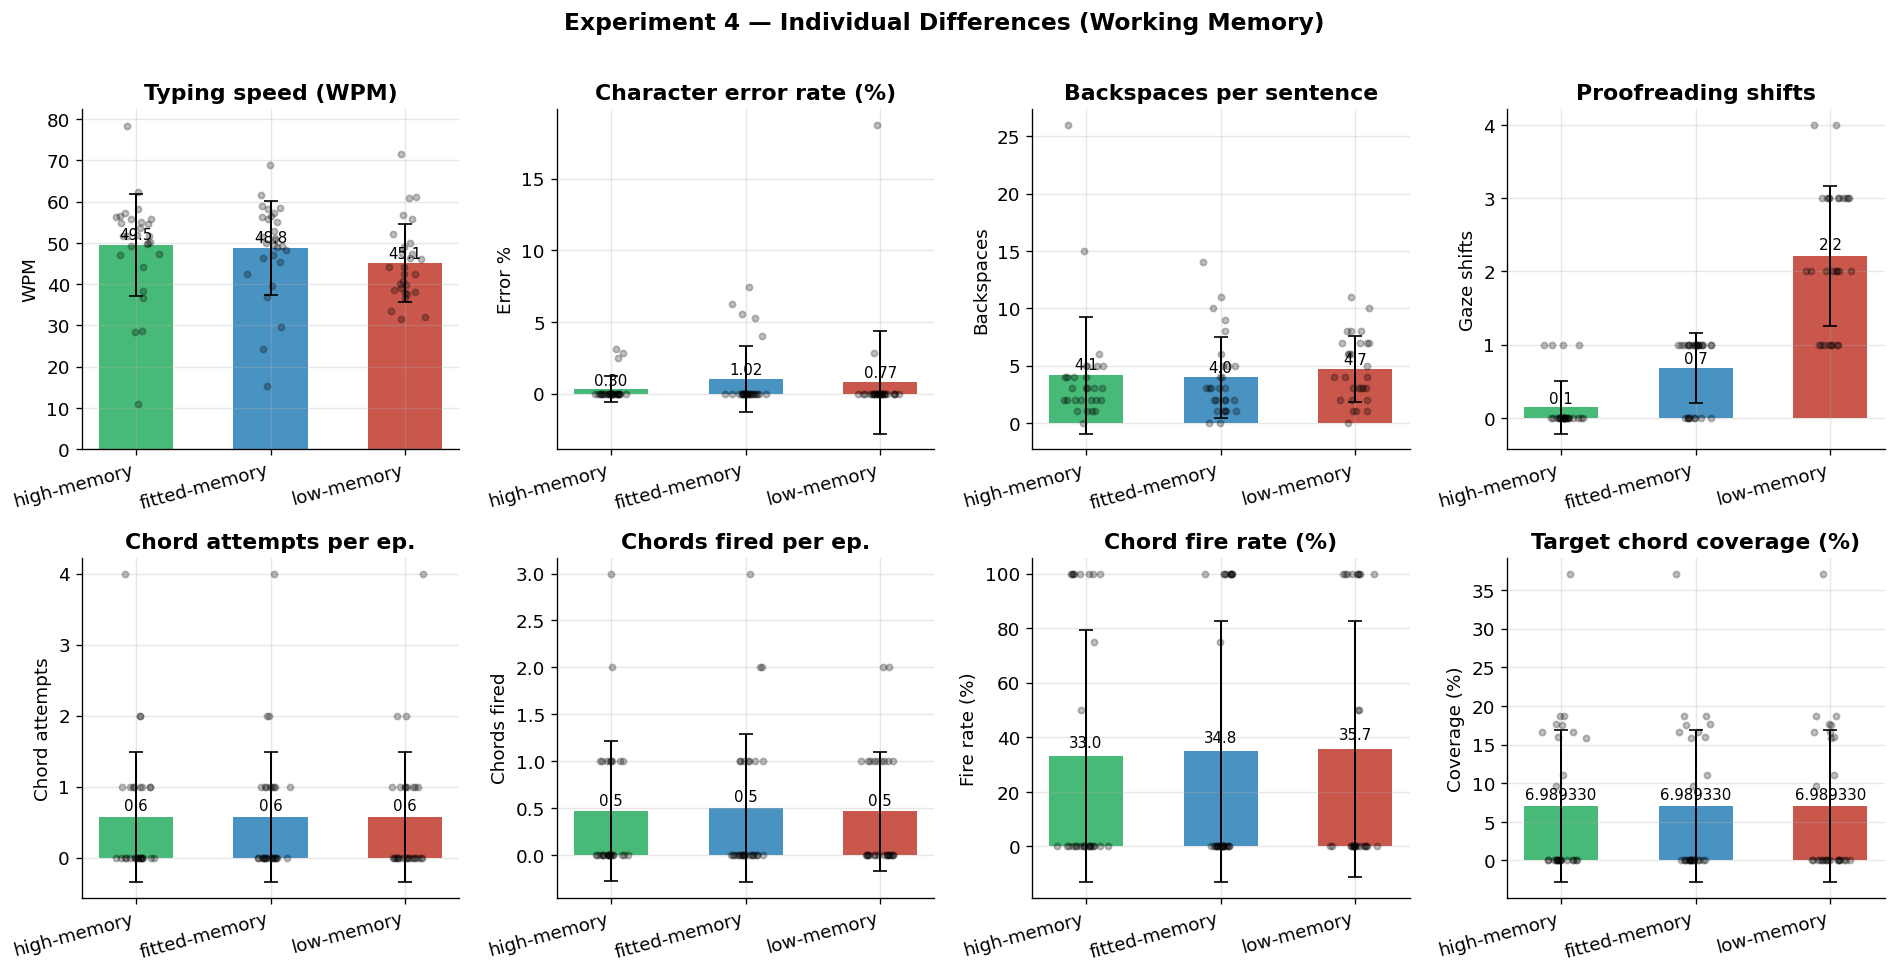

In [13]:
ORDER_INDIV  = ['high-memory', 'fitted-memory', 'low-memory']
COLORS_INDIV = ['#27AE60', '#2980B9', '#C0392B']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Experiment 4 — Individual Differences (Working Memory)', fontsize=14, fontweight='bold', y=1.01)

for ax, (metric, ylabel, title, fmt) in zip(axes.flat, specs2):
    bar_chart2(indiv_df, metric, ORDER_INDIV, COLORS_INDIV, ylabel, title, ax, fmt)

plt.tight_layout()
plt.savefig('results/exp4_individual_diff.png', bbox_inches='tight')
plt.show()

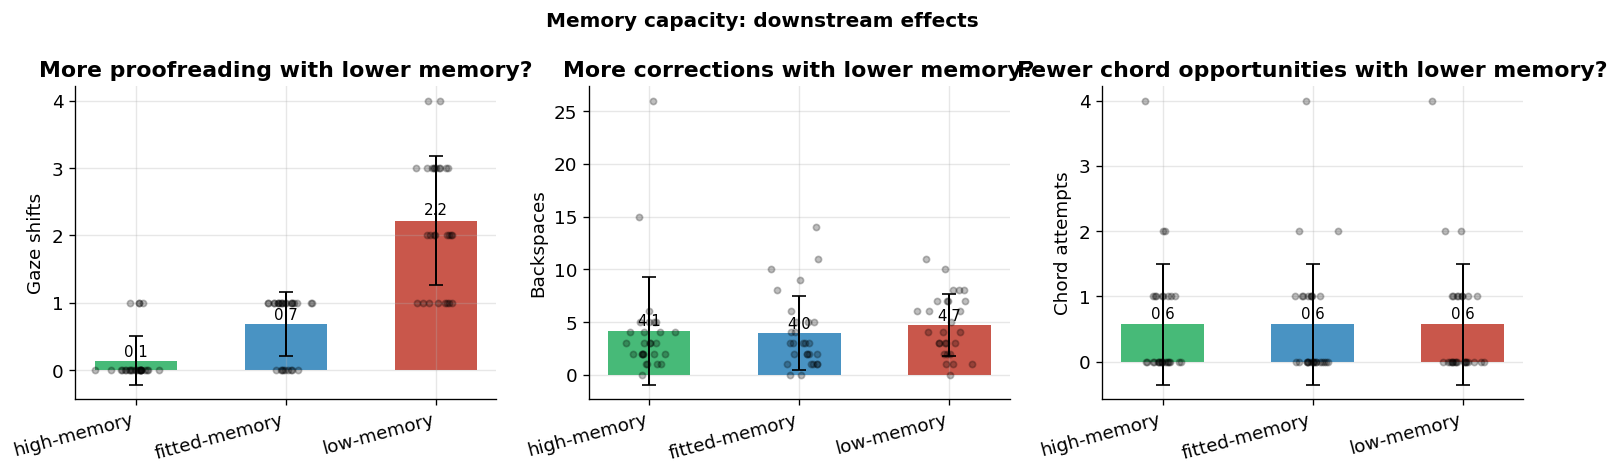

In [14]:
# Memory's effect on proofreading vs. chord behavior
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Memory capacity: downstream effects', fontsize=12, fontweight='bold')

effect_specs = [
    ('gaze_shift',     'Gaze shifts',   'More proofreading with lower memory?'),
    ('num_backspaces', 'Backspaces',    'More corrections with lower memory?'),
    ('chord_attempts', 'Chord attempts','Fewer chord opportunities with lower memory?'),
]

for ax, (metric, ylabel, title) in zip(axes, effect_specs):
    bar_chart2(indiv_df, metric, ORDER_INDIV, COLORS_INDIV, ylabel, title, ax)

plt.tight_layout()
plt.savefig('results/exp4_memory_effects.png', bbox_inches='tight')
plt.show()

In [15]:
# Numeric summary
print('Individual differences — mean (SD):')
metrics4 = ['WPM', 'error_pct', 'num_backspaces', 'gaze_shift', 'chord_attempts', 'fire_rate_pct']
labels4  = ['WPM', 'Error %', 'Backspaces', 'Gaze shifts', 'Chord attempts', 'Fire rate %']

rows = []
for cond in ORDER_INDIV:
    sub = indiv_df[indiv_df['condition'] == cond]
    row = {'Memory level': cond, 'n': len(sub)}
    for m, l in zip(metrics4, labels4):
        row[l] = f"{sub[m].mean():.2f} ({sub[m].std():.2f})"
    rows.append(row)
print(pd.DataFrame(rows).set_index('Memory level').to_string())

print()
print('WPM change high→low memory:')
hi  = indiv_df[indiv_df['condition']=='high-memory']['WPM'].mean()
lo  = indiv_df[indiv_df['condition']=='low-memory']['WPM'].mean()
print(f'  Δ = {lo - hi:+.2f} WPM ({(lo-hi)/hi*100:+.1f}%)')

Individual differences — mean (SD):
                n            WPM      Error %   Backspaces  Gaze shifts Chord attempts    Fire rate %
Memory level                                                                                         
high-memory    28  49.51 (12.39)  0.30 (0.89)  4.14 (5.08)  0.14 (0.36)    0.57 (0.92)  33.04 (46.17)
fitted-memory  28  48.76 (11.47)  1.02 (2.27)  3.96 (3.52)  0.68 (0.48)    0.57 (0.92)  34.82 (47.79)
low-memory     28   45.09 (9.52)  0.77 (3.56)  4.71 (2.90)  2.21 (0.96)    0.57 (0.92)  35.71 (46.86)

WPM change high→low memory:
  Δ = -4.43 WPM (-8.9%)


---
## Cross-experiment Summary

A single table comparing the best condition from each experiment to a common baseline (two-thumb typing).

In [16]:
baseline = mode_df[mode_df['condition'] == 'two-thumb']

comparisons = [
    ('Two-thumb (baseline)',      baseline),
    ('+ Chording (10 chords)',    mode_df[mode_df['condition'] == 'chording']),
    ('+ Vocab-2 (minimal)',       vocab_df[vocab_df['condition'] == 'vocab-2']),
    ('+ Vocab-10 (full)',         vocab_df[vocab_df['condition'] == 'vocab-10']),
    ('+ Graduated difficulty',    diff_df[diff_df['condition'] == 'graduated']),
    ('+ High memory',             indiv_df[indiv_df['condition'] == 'high-memory']),
    ('+ Low memory',              indiv_df[indiv_df['condition'] == 'low-memory']),
]

summary_metrics = ['WPM', 'IKI', 'error_pct', 'num_backspaces', 'gaze_shift', 'fire_rate_pct']
summary_labels  = ['WPM', 'IKI (ms)', 'Error %', 'Backspaces', 'Gaze shifts', 'Fire rate %']

rows = []
base_means = {m: baseline[m].mean() for m in summary_metrics}
for label, sub in comparisons:
    row = {'Condition': label, 'n': len(sub)}
    for m, l in zip(summary_metrics, summary_labels):
        mean = sub[m].mean()
        sd   = sub[m].std()
        delta = mean - base_means[m]
        row[l] = f"{mean:.1f} ({'±' if delta == 0 else ('+' if delta > 0 else '')}{delta:.1f})"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Condition')
print('Values shown as: mean (Δ vs two-thumb baseline)')
print()
print(summary_df.to_string())

Values shown as: mean (Δ vs two-thumb baseline)

                         n           WPM       IKI (ms)     Error %  Backspaces Gaze shifts   Fire rate %
Condition                                                                                                
Two-thumb (baseline)    30   36.8 (±0.0)   298.2 (±0.0)  2.9 (±0.0)  6.9 (±0.0)  5.5 (±0.0)    0.0 (±0.0)
+ Chording (10 chords)  28  48.0 (+11.1)  271.6 (-26.6)  0.8 (-2.1)  4.2 (-2.7)  0.8 (-4.8)  34.8 (+34.8)
+ Vocab-2 (minimal)     28  47.1 (+10.3)  274.5 (-23.7)  0.2 (-2.7)  3.5 (-3.4)  0.9 (-4.6)  17.9 (+17.9)
+ Vocab-10 (full)       28  49.0 (+12.1)  270.8 (-27.4)  0.1 (-2.8)  3.6 (-3.3)  0.8 (-4.7)  31.2 (+31.2)
+ Graduated difficulty  28  49.5 (+12.7)  271.8 (-26.4)  0.7 (-2.2)  3.6 (-3.3)  0.8 (-4.7)  38.4 (+38.4)
+ High memory           28  49.5 (+12.7)  265.6 (-32.6)  0.3 (-2.6)  4.1 (-2.8)  0.1 (-5.4)  33.0 (+33.0)
+ Low memory            28   45.1 (+8.2)  274.6 (-23.6)  0.8 (-2.2)  4.7 (-2.2)  2.2 (-3.3)  35.7 (+35.

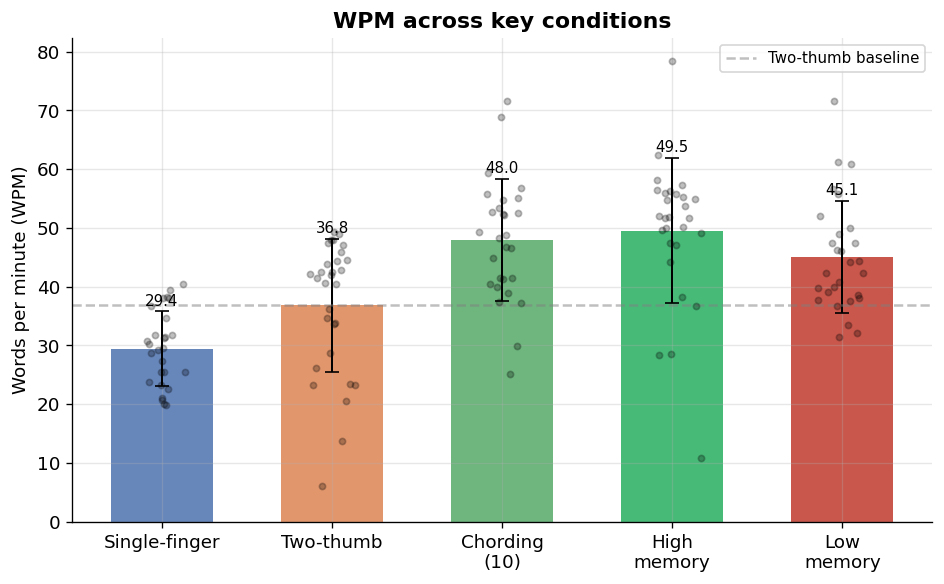

In [17]:
# WPM lift overview — all best conditions on one chart
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = [
    ('Single-finger',   mode_df[mode_df['condition']=='single-finger']['WPM'],   '#4C72B0'),
    ('Two-thumb',       mode_df[mode_df['condition']=='two-thumb']['WPM'],       '#DD8452'),
    ('Chording\n(10)',  mode_df[mode_df['condition']=='chording']['WPM'],        '#55A868'),
    ('High\nmemory',    indiv_df[indiv_df['condition']=='high-memory']['WPM'],   '#27AE60'),
    ('Low\nmemory',     indiv_df[indiv_df['condition']=='low-memory']['WPM'],    '#C0392B'),
]

positions = np.arange(len(plot_data))
for pos, (label, vals, color) in zip(positions, plot_data):
    ax.bar(pos, vals.mean(), color=color, alpha=0.85, width=0.6,
           yerr=vals.std(), capsize=4, error_kw={'linewidth': 1.2})
    ax.scatter(np.random.normal(pos, 0.07, len(vals)), vals,
               color='black', alpha=0.25, s=14, zorder=3)
    ax.text(pos, vals.mean() + vals.std() + 0.5,
            f'{vals.mean():.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(positions)
ax.set_xticklabels([l for l, _, _ in plot_data])
ax.set_ylabel('Words per minute (WPM)')
ax.set_title('WPM across key conditions', fontweight='bold')
ax.axhline(baseline['WPM'].mean(), color='gray', linestyle='--', alpha=0.5, label='Two-thumb baseline')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('results/wpm_overview.png', bbox_inches='tight')
plt.show()

---
## Key Findings

Run the cell below to auto-generate a plain-text summary based on the actual data.

In [18]:
def mean(df, cond, metric):
    return df[df['condition'] == cond][metric].mean()

sf_wpm   = mean(mode_df, 'single-finger', 'WPM')
tt_wpm   = mean(mode_df, 'two-thumb',     'WPM')
ch_wpm   = mean(mode_df, 'chording',      'WPM')
v2_wpm   = mean(vocab_df, 'vocab-2',      'WPM')
v10_wpm  = mean(vocab_df, 'vocab-10',     'WPM')
ue_fire  = mean(diff_df, 'uniform-easy',  'fire_rate_pct')
uh_fire  = mean(diff_df, 'uniform-hard',  'fire_rate_pct')
gr_fire  = mean(diff_df, 'graduated',     'fire_rate_pct')
hi_wpm   = mean(indiv_df,'high-memory',   'WPM')
lo_wpm   = mean(indiv_df,'low-memory',    'WPM')

print("="*65)
print("KEY FINDINGS")
print("="*65)
print()
print("1. TYPING MODE")
print(f"   Single-finger → two-thumb: +{tt_wpm-sf_wpm:.1f} WPM ({(tt_wpm-sf_wpm)/sf_wpm*100:.0f}%)")
print(f"   Two-thumb → chording:      {ch_wpm-tt_wpm:+.1f} WPM ({(ch_wpm-tt_wpm)/tt_wpm*100:.0f}%)")
print(f"   Chord fire rate: {mean(mode_df,'chording','fire_rate_pct'):.1f}%")
print()
print("2. VOCABULARY SIZE")
print(f"   Vocab-2 WPM: {v2_wpm:.1f}  |  Vocab-10 WPM: {v10_wpm:.1f}  |  Δ = {v10_wpm-v2_wpm:+.1f}")
print(f"   Coverage  : vocab-2={mean(vocab_df,'vocab-2','chord_cov_pct'):.1f}%  "
      f"vocab-10={mean(vocab_df,'vocab-10','chord_cov_pct'):.1f}%")
print()
print("3. DIFFICULTY ASSIGNMENT")
print(f"   Fire rate: easy={ue_fire:.1f}%  graduated={gr_fire:.1f}%  hard={uh_fire:.1f}%")
print(f"   WPM:       easy={mean(diff_df,'uniform-easy','WPM'):.1f}  "
      f"graduated={mean(diff_df,'graduated','WPM'):.1f}  hard={mean(diff_df,'uniform-hard','WPM'):.1f}")
print()
print("4. INDIVIDUAL DIFFERENCES")
print(f"   High memory: {hi_wpm:.1f} WPM  |  Low memory: {lo_wpm:.1f} WPM  |  Δ = {lo_wpm-hi_wpm:+.1f}")
print(f"   Backspaces: high={mean(indiv_df,'high-memory','num_backspaces'):.1f}  "
      f"low={mean(indiv_df,'low-memory','num_backspaces'):.1f}")
print(f"   Chord attempts: high={mean(indiv_df,'high-memory','chord_attempts'):.1f}  "
      f"low={mean(indiv_df,'low-memory','chord_attempts'):.1f}")
print("="*65)

KEY FINDINGS

1. TYPING MODE
   Single-finger → two-thumb: +7.4 WPM (25%)
   Two-thumb → chording:      +11.1 WPM (30%)
   Chord fire rate: 34.8%

2. VOCABULARY SIZE
   Vocab-2 WPM: 47.1  |  Vocab-10 WPM: 49.0  |  Δ = +1.9
   Coverage  : vocab-2=2.6%  vocab-10=7.0%

3. DIFFICULTY ASSIGNMENT
   Fire rate: easy=33.9%  graduated=38.4%  hard=35.7%
   WPM:       easy=50.5  graduated=49.5  hard=49.2

4. INDIVIDUAL DIFFERENCES
   High memory: 49.5 WPM  |  Low memory: 45.1 WPM  |  Δ = -4.4
   Backspaces: high=4.1  low=4.7
   Chord attempts: high=0.6  low=0.6
